🚀 Starting simulation for 1000 users...

--- PERFORMANCE SUMMARY ---
Average Wait (Nearest): 15.22 mins
Average Wait (Smart RSU): 10.36 mins
🔥 Wait Time Reduction: 31.9%


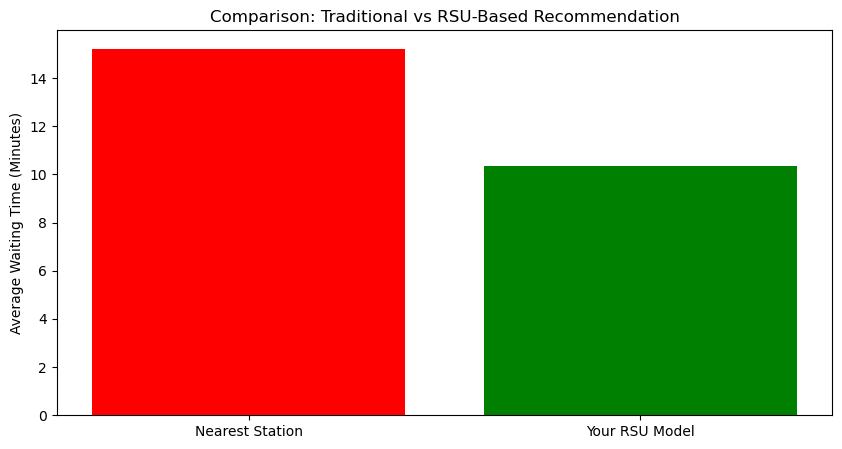

In [1]:
import pandas as pd
import numpy as np
import pickle
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

# 1. LOAD DATA
model = pickle.load(open('ev_xgboost_model.pkl', 'rb'))
df_stations = pd.read_csv('stations_data.csv')
df_ground_truth = pd.read_csv('rsu_live_feed.csv')
df_ground_truth['timestamp'] = pd.to_datetime(df_ground_truth['timestamp'])

# SIMULATION SETTINGS
NUM_USERS = 1000
DELHI_BOUNDS = {'lat': (28.4, 28.8), 'lon': (77.0, 77.4)}
AVG_SPEED_KMPH = 25  # Delhi city traffic average

def get_wait_time(actual_free, total_slots):
    """Wait time based on actual ground truth slots available"""
    if actual_free >= 1:
        return 0
    else:
        # Standard penalty logic: if full, wait proportional to hub size
        return 30 / total_slots 

results = []

print(f"🚀 Starting simulation for {NUM_USERS} users...")

for i in range(NUM_USERS):
    # Create a random user
    u_lat = np.random.uniform(DELHI_BOUNDS['lat'][0], DELHI_BOUNDS['lat'][1])
    u_lon = np.random.uniform(DELHI_BOUNDS['lon'][0], DELHI_BOUNDS['lon'][1])
    
    # Pick a random "Now" from the 24h simulation (excluding late night)
    start_hour = np.random.randint(8, 21) 
    now = df_ground_truth['timestamp'].iloc[0].replace(hour=start_hour, minute=np.random.randint(0, 59))
    
    # PRE-FILTER: Get 10 candidates by air distance
    df_stations['air_dist'] = np.sqrt((df_stations['latitude']-u_lat)**2 + (df_stations['longitude']-u_lon)**2) * 111
    candidates = df_stations.nsmallest(10, 'air_dist').copy()
    
    # --- STRATEGY A: NAIVE (NEAREST) ---
    nearest = candidates.iloc[0]
    n_travel_time = (nearest['air_dist'] / AVG_SPEED_KMPH) * 60
    n_arrival = now + timedelta(minutes=n_travel_time)
    
    # Lookup Ground Truth at arrival time
    n_truth = df_ground_truth[(df_ground_truth['station_id'] == nearest['station_id']) & 
                              (df_ground_truth['timestamp'].dt.hour == n_arrival.hour)].iloc[0]
    n_wait = get_wait_time(n_truth['free_now'], nearest['charging_points'])
    
    # --- STRATEGY B: YOUR RSU MODEL ---
    smart_list = []
    for _, stn in candidates.iterrows():
        # 1. Travel time
        s_travel_time = (stn['air_dist'] / AVG_SPEED_KMPH) * 60
        s_arrival = now + timedelta(minutes=s_travel_time)
        
        # 2. RSU Look-back (What the model sees 'Now')
        rsu_now = df_ground_truth[(df_ground_truth['station_id'] == stn['station_id']) & 
                                  (df_ground_truth['timestamp'] <= now)].tail(3)
        
        curr_occ = rsu_now['occupied_now'].iloc[-1]
        prev_occ = rsu_now['occupied_now'].iloc[-2] if len(rsu_now)>1 else curr_occ
        
        # 3. XGBoost Prediction for arrival
        feat = pd.DataFrame([{
            'hour': s_arrival.hour, 'day_of_week': now.weekday(), 'is_weekend': 0,
            'total_slots': stn['charging_points'], 'prev_occupied_1': curr_occ,
            'occ_change': curr_occ - prev_occ, 'rolling_avg_3': rsu_now['occupied_now'].mean()
        }])
        pred_occ = model.predict(feat)[0]
        pred_free = stn['charging_points'] - pred_occ
        
        # 4. Recommendation Score
        p_wait = (30 / stn['charging_points']) if pred_free < 1 else 0
        score = s_travel_time + p_wait
        smart_list.append({'stn_id': stn['station_id'], 'score': score, 'travel': s_travel_time, 'arrival_h': s_arrival.hour, 'total': stn['charging_points']})
        
    # Pick the best according to model
    best_smart = pd.DataFrame(smart_list).sort_values('score').iloc[0]
    
    # Get ACTUAL ground truth wait time for the smart choice
    s_truth = df_ground_truth[(df_ground_truth['station_id'] == best_smart['stn_id']) & 
                              (df_ground_truth['timestamp'].dt.hour == best_smart['arrival_h'])].iloc[0]
    s_wait = get_wait_time(s_truth['free_now'], best_smart['total'])
    
    results.append({
        'naive_wait': n_wait, 'naive_total': n_wait + n_travel_time,
        'smart_wait': s_wait, 'smart_total': s_wait + best_smart['travel']
    })

# 3. ANALYSIS
df_res = pd.DataFrame(results)
print("\n--- PERFORMANCE SUMMARY ---")
print(f"Average Wait (Nearest): {df_res['naive_wait'].mean():.2f} mins")
print(f"Average Wait (Smart RSU): {df_res['smart_wait'].mean():.2f} mins")
improvement = ((df_res['naive_wait'].mean() - df_res['smart_wait'].mean()) / df_res['naive_wait'].mean()) * 100
print(f"🔥 Wait Time Reduction: {improvement:.1f}%")

# 4. PLOT RESULTS
plt.figure(figsize=(10, 5))
plt.bar(['Nearest Station', 'Your RSU Model'], [df_res['naive_wait'].mean(), df_res['smart_wait'].mean()], color=['red', 'green'])
plt.ylabel('Average Waiting Time (Minutes)')
plt.title('Comparison: Traditional vs RSU-Based Recommendation')
plt.show()
